ROC AUC: 0.6858
Accuracy: 0.5621
Recall(most important): 0.7917


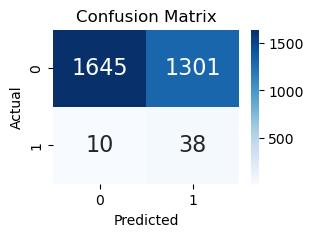

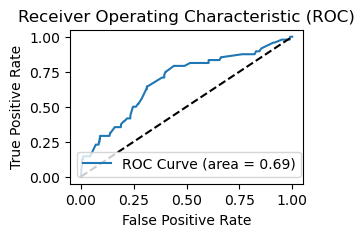

ROC AUC: 0.6836
Accuracy: 0.6723
Recall(most important): 0.6458


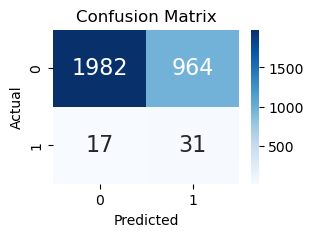

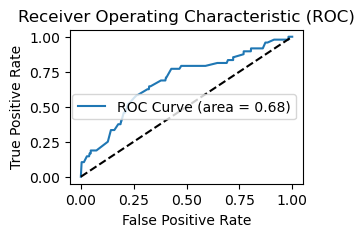

ROC AUC: 0.6649
Accuracy: 0.5935
Recall(most important): 0.6875


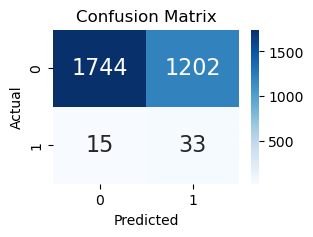

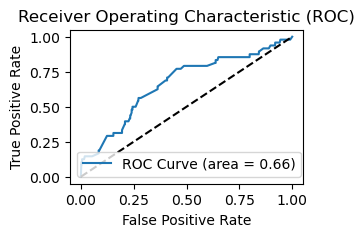

ROC AUC: 0.6763
Accuracy: 0.5261
Recall(most important): 0.7083


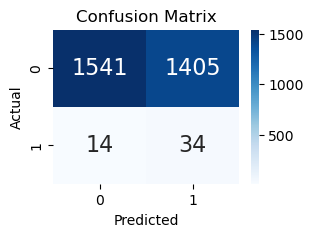

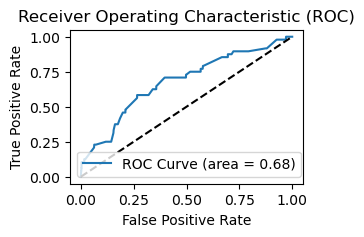

ROC AUC: 0.6964
Accuracy: 0.5895
Recall(most important): 0.7292


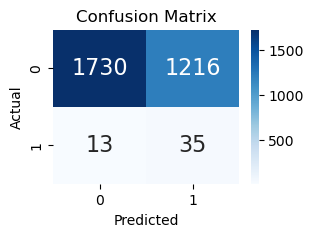

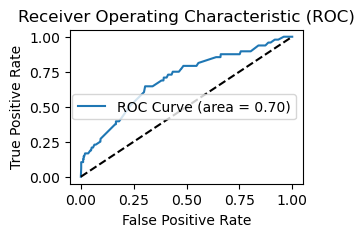

(0.5621242484969939, 0.7916666666666666, 0.6857674247567322)
(0.6723446893787575, 0.6458333333333334, 0.6836423681828467)
(0.5935203740814963, 0.6875, 0.6649199479520252)
(0.5260521042084169, 0.7083333333333334, 0.6763408010862186)
(0.5895123580494323, 0.7291666666666666, 0.6964457456438109)
Mean Accuracy: 0.589
Mean Recall: 0.71
Mean ROC AUC: 0.681


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
# from xgboost import XGBClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def normalize2(row, mean_df, std_df, athlete_id):
    '''
    Normalize the data using z-score normalization.
    '''
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

def getMeanStd(data):
    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getBalancedSubset(X_train, samplesPerClass):
    '''
    Create a balanced subset of the data by sampling from each athlete's data.
    '''
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()
    
    stats = pd.DataFrame(X_train[['Athlete ID','injury']].groupby(['Athlete ID','injury']).size().reset_index(name='counts'))
    stats = pd.DataFrame(stats[['Athlete ID']].groupby(['Athlete ID']).size().reset_index(name='counts'))
    stats.drop(stats[stats['counts'] < 2].index, inplace=True)
    athleteList = stats['Athlete ID'].unique()

    samplesPerAthlete = int(np.floor(samplesPerClass) / len(athleteList))

    for athlete in athleteList:
        if unhealthySet.empty:
            unhealthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete, replace=True)
        else:
            unhealthySet = pd.concat([unhealthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete,replace=True)], ignore_index=True)
        if healthySet.empty:
            healthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete, replace=True)
        else:
            healthySet = pd.concat([healthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete,replace=True)], ignore_index=True)


    balancedSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return balancedSet


def preparedata(df,test_athletes):
    '''
    Prepare the data for training and testing.
    This includes normalization, creating a balanced subset of the data, and splitting into training and testing sets.
    '''
    X_test_original = df[df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
    X_train_original = df[~df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy

    X_train_means, X_train_std = getMeanStd(X_train_original)
    X_test_means, X_test_std = getMeanStd(X_test_original)
    X_train_balanced = getBalancedSubset(X_train_original.copy(), 2048)
    
    # Set target variable for testing and training
    y_train = X_train_balanced['injury']
    y_test = X_test_original['injury']

    # Apply normalization to the balanced training data
    X_train_norm = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
    X_train_norm = X_train_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

    # Apply normalization to the test data using the testing statistics
    # Note this is a source of data leakage! but the alternative is not feasible
    X_test_norm = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
    X_test_norm = X_test_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


    return y_train, y_test, X_train_norm, X_test_norm

def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)

def eval(model, y_true, X, y_pred, **params):
    '''
    Produce key evaluation metrics without visualisations.
    '''
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, Recall(most important): {recall:.3f}")
   
    return (accuracy,recall,roc_auc)

def run_exps(df,test_set, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = preparedata(df, test_set)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model
    
    
def main():
    '''
    Main function to run the experiments.
    '''

    # Load, clean, and split the data
    dfday = pd.read_csv('../data/combodf.csv')
    dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)
    athletes = sorted(list(dfday['Athlete ID'].unique()))
    test_athletes = athletes[len(athletes) - 10:]

    # run experiments to determine the best model
    best_model = run_exps(dfday, test_athletes, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)
   
    # Save the model to a file
    # with open('../models/logistic_model.pkl', 'wb') as f:
    #    pickle.dump(best_model, f)

    
    # Uncomment the following lines to run additional experiments with different hyperparameters
    '''
    print("-" * 50)  # Separator for better readability
    C_values = [0.001, 0.01, 0.1, 1, 10]
    l1_ratio_values = [0.2, 0.5, 0.8]
    for C in C_values:
        for l1_ratio in l1_ratio_values:
            print(f"Running experiments with C={C}, l1_ratio={l1_ratio}, penalty='elasticnet', solver='saga', class_weight='balanced'")
            run_exps(dfday, test_athletes, n = 3, C=C, penalty='elasticnet', solver='saga', l1_ratio=l1_ratio)
            print("-" * 50)  # Separator for better readability
   '''
   
main()

### next attempt with no normalisation
Change the preparedata function to exclude normalisation and rerun

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5824
Accuracy: 0.4937
Recall(most important): 0.6458


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


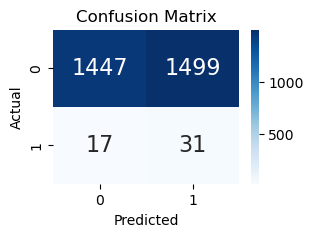

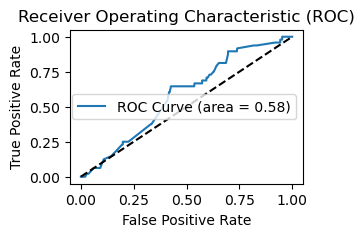

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5730
Accuracy: 0.4840
Recall(most important): 0.6667


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


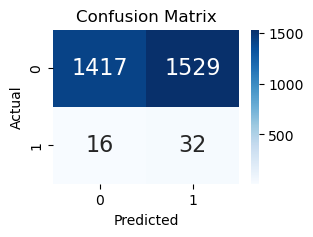

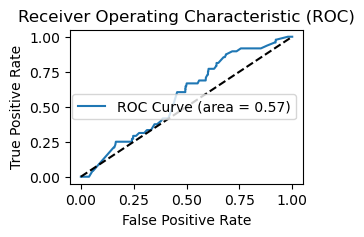

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5924
Accuracy: 0.4923
Recall(most important): 0.6667


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


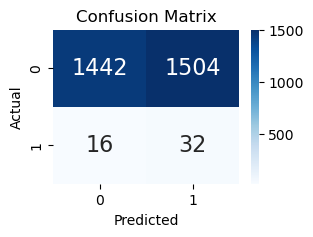

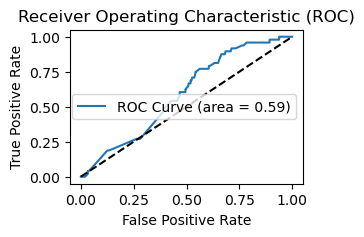

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5965
Accuracy: 0.5351
Recall(most important): 0.6250


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


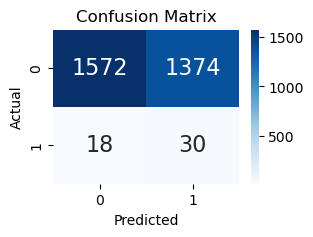

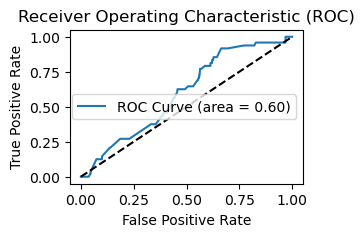

c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


ROC AUC: 0.5789
Accuracy: 0.5217
Recall(most important): 0.6458


c:\Users\milo\Anaconda3\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


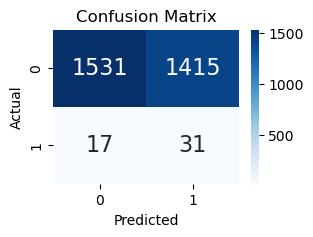

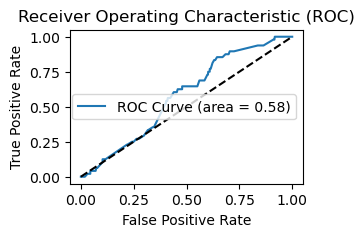

(0.49365397461589844, 0.6458333333333334, 0.5823998642226749)
(0.48396793587174347, 0.6666666666666666, 0.5729979916270649)
(0.4923179692718771, 0.6666666666666666, 0.5923533322018556)
(0.5350701402805611, 0.625, 0.5964938334464811)
(0.5217100868403474, 0.6458333333333334, 0.5789205702647657)
Mean Accuracy: 0.505
Mean Recall: 0.65
Mean ROC AUC: 0.585


In [3]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
# from xgboost import XGBClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# def norm ...

def getMeanStd(data):
    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getBalancedSubset(X_train, samplesPerClass):
    '''
    Create a balanced subset of the data by sampling from each athlete's data.
    '''
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()
    
    stats = pd.DataFrame(X_train[['Athlete ID','injury']].groupby(['Athlete ID','injury']).size().reset_index(name='counts'))
    stats = pd.DataFrame(stats[['Athlete ID']].groupby(['Athlete ID']).size().reset_index(name='counts'))
    stats.drop(stats[stats['counts'] < 2].index, inplace=True)
    athleteList = stats['Athlete ID'].unique()

    samplesPerAthlete = int(np.floor(samplesPerClass) / len(athleteList))

    for athlete in athleteList:
        if unhealthySet.empty:
            unhealthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete, replace=True)
        else:
            unhealthySet = pd.concat([unhealthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 0)].sample(samplesPerAthlete,replace=True)], ignore_index=True)
        if healthySet.empty:
            healthySet = X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete, replace=True)
        else:
            healthySet = pd.concat([healthySet, X_train[(X_train['Athlete ID'] == athlete) & (X_train['injury'] == 1)].sample(samplesPerAthlete,replace=True)], ignore_index=True)


    balancedSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return balancedSet


def preparedata(df,test_athletes):
    '''
    Prepare the data for training and testing.
    This includes normalization, creating a balanced subset of the data, and splitting into training and testing sets.
    '''
    X_test_original = df[df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
    X_train_original = df[~df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy

    X_train_means, X_train_std = getMeanStd(X_train_original)
    X_test_means, X_test_std = getMeanStd(X_test_original)
    X_train_balanced = getBalancedSubset(X_train_original.copy(), 2048)
    
    # Set target variable for testing and training
    y_train = X_train_balanced['injury']
    y_test = X_test_original['injury']

    # Apply normalization to the balanced training data
    # X_train_norm = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
    X_train = X_train_balanced.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

    # Apply normalization to the test data using the testing statistics
    # Note this is a source of data leakage! but the alternative is not feasible
    #X_test_norm = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
    X_test = X_test_original.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


    return y_train, y_test, X_train, X_test

def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)

def eval(model, y_true, X, y_pred, **params):
    '''
    Produce key evaluation metrics without visualisations.
    '''
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, Recall(most important): {recall:.3f}")
   
    return (accuracy,recall,roc_auc)

def run_exps(df,test_set, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = preparedata(df, test_set)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model
    
    
def main():
    '''
    Main function to run the experiments.
    '''

    # Load, clean, and split the data
    dfday = pd.read_csv('../data/combodf.csv')
    dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)
    athletes = sorted(list(dfday['Athlete ID'].unique()))
    test_athletes = athletes[len(athletes) - 10:]

    # run experiments to determine the best model
    best_model = run_exps(dfday, test_athletes, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)
   
    # Save the model to a file
    # with open('../models/logistic_model.pkl', 'wb') as f:
    #    pickle.dump(best_model, f)

    
    # Uncomment the following lines to run additional experiments with different hyperparameters
    '''
    print("-" * 50)  # Separator for better readability
    C_values = [0.001, 0.01, 0.1, 1, 10]
    l1_ratio_values = [0.2, 0.5, 0.8]
    for C in C_values:
        for l1_ratio in l1_ratio_values:
            print(f"Running experiments with C={C}, l1_ratio={l1_ratio}, penalty='elasticnet', solver='saga', class_weight='balanced'")
            run_exps(dfday, test_athletes, n = 3, C=C, penalty='elasticnet', solver='saga', l1_ratio=l1_ratio)
            print("-" * 50)  # Separator for better readability
   '''
   
main()

(0.5621242484969939, 0.7916666666666666, 0.6857674247567322)
(0.6723446893787575, 0.6458333333333334, 0.6836423681828467)
(0.5935203740814963, 0.6875, 0.6649199479520252)
(0.5260521042084169, 0.7083333333333334, 0.6763408010862186)
(0.5895123580494323, 0.7291666666666666, 0.6964457456438109)
Mean Accuracy: 0.589
Mean Recall: 0.71
Mean ROC AUC: 0.681

- with no normalisation

(0.49365397461589844, 0.6458333333333334, 0.5823998642226749)
(0.48396793587174347, 0.6666666666666666, 0.5729979916270649)
(0.4923179692718771, 0.6666666666666666, 0.5923533322018556)
(0.5350701402805611, 0.625, 0.5964938334464811)
(0.5217100868403474, 0.6458333333333334, 0.5789205702647657)
Mean Accuracy: 0.505
Mean Recall: 0.65
Mean ROC AUC: 0.585

a definite drop in accuracy. volume per athlete seems to matter significantly more than total volume. 

what if I don't subset by athlete and instead subset the whole thing? I mean they're normalised right?

so without subsetting by athlete it seems I don't lose too much. but here I am still splitting the data the same way I think. how would that go for me?

(0.5591182364729459, 0.6666666666666666, 0.673540393754243)
(0.5487641950567802, 0.7291666666666666, 0.6910570830504639)
(0.6205744822979292, 0.6875, 0.6954521667798144)
(0.5177020708082832, 0.7083333333333334, 0.691933978275628)
(0.5895123580494323, 0.7291666666666666, 0.7041751527494908)
Mean Accuracy: 0.567
Mean Recall: 0.70
Mean ROC AUC: 0.691


ROC AUC: 0.6735
Accuracy: 0.5591
Recall(most important): 0.6667


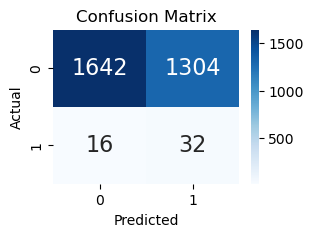

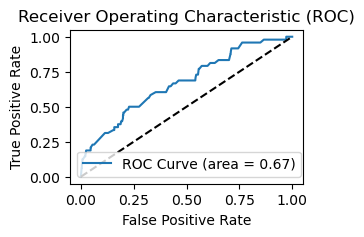

ROC AUC: 0.6911
Accuracy: 0.5488
Recall(most important): 0.7292


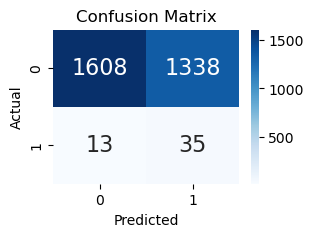

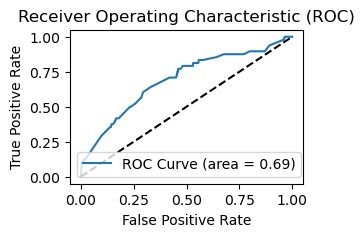

ROC AUC: 0.6955
Accuracy: 0.6206
Recall(most important): 0.6875


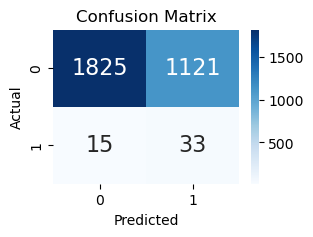

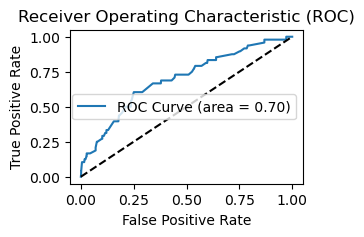

ROC AUC: 0.6919
Accuracy: 0.5177
Recall(most important): 0.7083


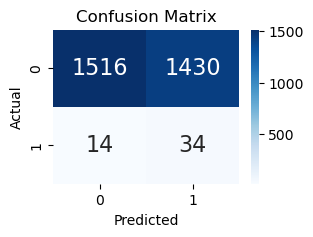

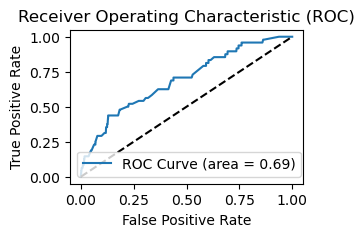

ROC AUC: 0.7042
Accuracy: 0.5895
Recall(most important): 0.7292


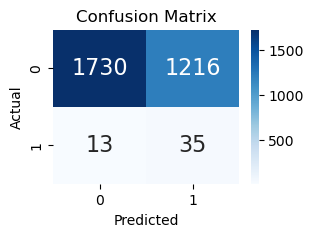

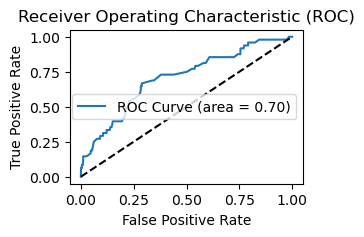

(0.5591182364729459, 0.6666666666666666, 0.673540393754243)
(0.5487641950567802, 0.7291666666666666, 0.6910570830504639)
(0.6205744822979292, 0.6875, 0.6954521667798144)
(0.5177020708082832, 0.7083333333333334, 0.691933978275628)
(0.5895123580494323, 0.7291666666666666, 0.7041751527494908)
Mean Accuracy: 0.567
Mean Recall: 0.70
Mean ROC AUC: 0.691


In [6]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
# from xgboost import XGBClassifier
# from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def normalize2(row, mean_df, std_df, athlete_id):
    '''
    Normalize the data using z-score normalization.
    '''
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

def getMeanStd(data):
    ''' 
    Calculate the mean and standard deviation for each athlete's data.
    This is used for normalization.
    '''

    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getregsubset(X_train, samplesPerClass):
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()

    unhealthySet = X_train[X_train['injury'] == 0].sample(samplesPerClass, replace=True)
    healthySet = X_train[X_train['injury'] == 1].sample(samplesPerClass, replace=True)


    regSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return regSet


def preparedata(df,test_athletes):
    '''
    Prepare the data for training and testing.
    This includes normalization, creating a balanced subset of the data, and splitting into training and testing sets.
    '''
    X_test_original = df[df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy for normalization
    X_train_original = df[~df['Athlete ID'].isin(test_athletes)].copy() # Keep a copy

    X_train_means, X_train_std = getMeanStd(X_train_original)
    X_test_means, X_test_std = getMeanStd(X_test_original)
    X_train_balanced = getregsubset(X_train_original.copy(), 2048)
    
    # Set target variable for testing and training
    y_train = X_train_balanced['injury']
    y_test = X_test_original['injury']

    # Apply normalization to the balanced training data
    X_train_norm = X_train_balanced.apply(lambda x: normalize2(x, X_train_means, X_train_std, x['Athlete ID']), axis=1)
    X_train_norm = X_train_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')

    # Apply normalization to the test data using the testing statistics
    # Note this is a source of data leakage! but the alternative is not feasible
    X_test_norm = X_test_original.apply(lambda x: normalize2(x, X_test_means, X_test_std, x['Athlete ID']), axis=1)
    X_test_norm = X_test_norm.drop(columns=['injury', 'Date', 'Athlete ID'], errors='ignore')


    return y_train, y_test, X_train_norm, X_test_norm

def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''
    # model = XGBClassifier()
    # model = GaussianNB()

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)

def eval(model, y_true, X, y_pred, **params):
    '''
    Produce key evaluation metrics without visualisations.
    '''
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, Recall(most important): {recall:.3f}")
   
    return (accuracy,recall,roc_auc)

def run_exps(df,test_set, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = preparedata(df, test_set)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model
    
    
def main():
    '''
    Main function to run the experiments.
    '''

    # Load, clean, and split the data
    dfday = pd.read_csv('../data/combodf.csv')
    dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)
    athletes = sorted(list(dfday['Athlete ID'].unique()))
    test_athletes = athletes[len(athletes) - 10:]

    # run experiments to determine the best model
    best_model = run_exps(dfday, test_athletes, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)
   
    # Save the model to a file
    # with open('../models/logistic_model.pkl', 'wb') as f:
    #    pickle.dump(best_model, f)

    
    # Uncomment the following lines to run additional experiments with different hyperparameters
    '''
    print("-" * 50)  # Separator for better readability
    C_values = [0.001, 0.01, 0.1, 1, 10]
    l1_ratio_values = [0.2, 0.5, 0.8]
    for C in C_values:
        for l1_ratio in l1_ratio_values:
            print(f"Running experiments with C={C}, l1_ratio={l1_ratio}, penalty='elasticnet', solver='saga', class_weight='balanced'")
            run_exps(dfday, test_athletes, n = 3, C=C, penalty='elasticnet', solver='saga', l1_ratio=l1_ratio)
            print("-" * 50)  # Separator for better readability
   '''
   
main()

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc

def normalize2(row, mean_df, std_df, athlete_id):
    '''
    Normalize the data using z-score normalization.
    '''
    mu = mean_df.loc[athlete_id]
    su = std_df.loc[athlete_id]
    z = (row - mu)/su
    return z

def getMeanStd(data):
    ''' 
    Calculate the mean and standard deviation for each athlete's data.
    This is used for normalization.
    '''

    mean = data[data['injury'] == 0].groupby('Athlete ID').mean()
    std = data[data['injury'] == 0].groupby('Athlete ID').std()
    std.replace(to_replace=0.0, value=0.01, inplace=True)
    return mean, std

def getregsubset(X_train, samplesPerClass):
    healthySet   = pd.DataFrame()
    unhealthySet = pd.DataFrame()

    unhealthySet = X_train[X_train['injury'] == 0].sample(samplesPerClass, replace=True)
    healthySet = X_train[X_train['injury'] == 1].sample(samplesPerClass, replace=True)


    regSet = pd.concat([healthySet, unhealthySet], ignore_index=True)
    return regSet


def train_model(X_train, y_train, **params):
    '''
    Train the model using the training data and some already tuned hyperparameters.
    This includes applying Platt scaling for better probability estimates.
    '''

    # Create and fit the logistic regression model
    model = LogisticRegression(**params, max_iter=500, class_weight='balanced')
    model.fit(X_train, y_train)

    # Apply Platt scaling with cross-validation
    calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)  # You can adjust cv as needed
    calibrated_model.fit(X_train, y_train)

    return calibrated_model

def vis_and_eval(model, y_true, X, y_pred):
    '''
    Produce key evaluation metrics and visualisations.
    '''
    conf_matrix = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    # Print evaluation metrics
    fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X)[:, 1])
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall(most important): {recall:.4f}")

    # Plot confusion matrix
    plt.figure(figsize=(3,2))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16})
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # print ROC curve and AUC
    plt.figure(figsize=(3,2))
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend()
    plt.show()

    return (accuracy,recall,roc_auc)


def run_exps(df, n =5, **params):
    '''
    Run experiments to determine the best model.
    This includes training n models with the given parameters,
    evaluating them, and printings some metrics for each one. 
    it then returns the best model based on recall.   
        
    '''
    best_model = None
    best_recall = 0
    all_results = []
    for i in range(n):
        y_train, y_test, X_train, X_test = prepare_split(df)
        model = train_model(X_train, y_train,**params)
        y_pred = model.predict(X_test)
# CHANGE HERE FOR VISUALISATION
        # results = eval(model, y_test, X_test, y_pred)
        results = vis_and_eval(model, y_test, X_test, y_pred)
        
        if results[1] > best_recall and results[0] > 0.65:
            best_model = model
            best_recall = results[1]
        all_results.append(results)
    _ =[print(i) for i in all_results]
    # rewrite three lines above as f strings with 3 decimal places
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    return best_model


  

In [ ]:
def prepare_split(df):
    '''
    subsets then splits the data for training and testing.

    '''
 
    # Create balanced subset
    df_means, df_std = getMeanStd(df)  
    df_balanced = getregsubset(df, 2048)
    df_cop= df_balanced.copy()
    
    # Normalize only the feature columns
    X_norm = df_balanced.apply(
        lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), axis=1)
    y = df_cop['injury']
    
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y,
        test_size= 0.3,
        random_state= 24,
        stratify=y  # This ensures same ratio of injured/non-injured in both sets
    )

    return y_train, y_test, X_train, X_test

In [14]:

dfday = pd.read_csv('../data/combodf.csv')
dfday.drop(list(dfday.filter(regex = 'perceived|sprinting|strength')), axis = 1, inplace = True)

ROC AUC: 0.6419
Accuracy: 0.6086
Recall(most important): 0.6987


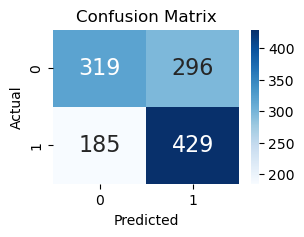

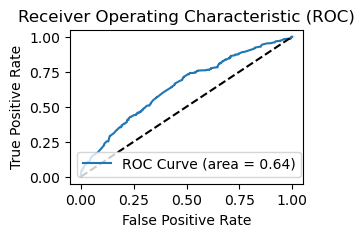

ROC AUC: 0.6454
Accuracy: 0.5989
Recall(most important): 0.5717


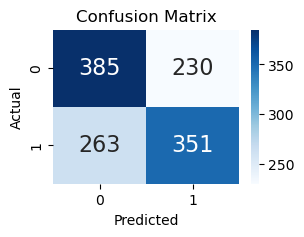

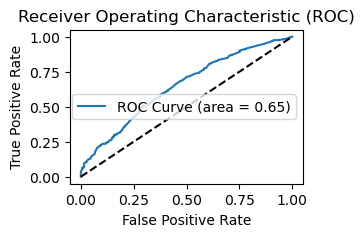

ROC AUC: 0.6434
Accuracy: 0.6046
Recall(most important): 0.5814


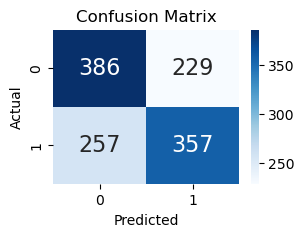

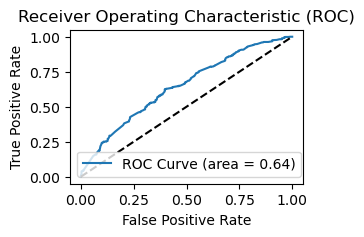

ROC AUC: 0.6279
Accuracy: 0.5972
Recall(most important): 0.6954


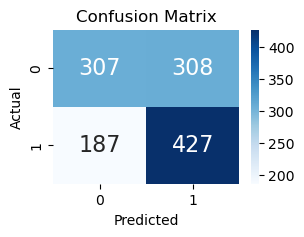

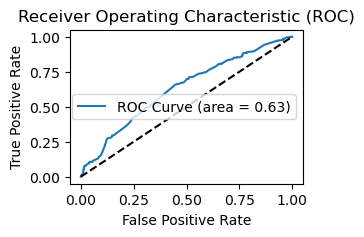

ROC AUC: 0.6613
Accuracy: 0.6257
Recall(most important): 0.6661


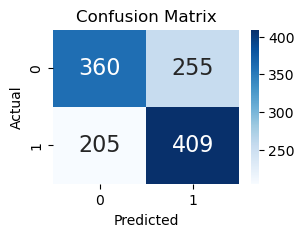

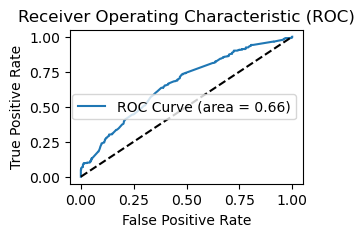

(0.6086248982912937, 0.6986970684039088, 0.6419149386933609)
(0.5988608624898292, 0.5716612377850163, 0.6454437117661078)
(0.6045565500406835, 0.5814332247557004, 0.6434495908477)
(0.597233523189585, 0.6954397394136808, 0.6278806175683906)
(0.6257119609438568, 0.6661237785016286, 0.661276184423082)
Mean Accuracy: 0.607
Mean Recall: 0.64
Mean ROC AUC: 0.644


In [26]:
best_model = run_exps(dfday, n = 5, C=0.01, penalty='elasticnet', solver='saga', l1_ratio=0.5)


(0.5621242484969939, 0.7916666666666666, 0.6857674247567322)
(0.6723446893787575, 0.6458333333333334, 0.6836423681828467)
(0.5935203740814963, 0.6875, 0.6649199479520252)
(0.5260521042084169, 0.7083333333333334, 0.6763408010862186)
(0.5895123580494323, 0.7291666666666666, 0.6964457456438109)
Mean Accuracy: 0.589
Mean Recall: 0.71
Mean ROC AUC: 0.681

- with no normalisation

(0.49365397461589844, 0.6458333333333334, 0.5823998642226749)
(0.48396793587174347, 0.6666666666666666, 0.5729979916270649)
(0.4923179692718771, 0.6666666666666666, 0.5923533322018556)
(0.5350701402805611, 0.625, 0.5964938334464811)
(0.5217100868403474, 0.6458333333333334, 0.5789205702647657)
Mean Accuracy: 0.505
Mean Recall: 0.65
Mean ROC AUC: 0.585

a definite drop in accuracy. volume per athlete seems to matter significantly more than total volume. 

what if I don't subset by athlete and instead subset the whole thing? I mean they're normalised right?

so without subsetting by athlete it seems I don't lose too much. but here I am still splitting the data the same way I think. how would that go for me?

(0.5591182364729459, 0.6666666666666666, 0.673540393754243)
(0.5487641950567802, 0.7291666666666666, 0.6910570830504639)
(0.6205744822979292, 0.6875, 0.6954521667798144)
(0.5177020708082832, 0.7083333333333334, 0.691933978275628)
(0.5895123580494323, 0.7291666666666666, 0.7041751527494908)
Mean Accuracy: 0.567
Mean Recall: 0.70
Mean ROC AUC: 0.691

this is with complete train test splitting rather than based on any 

(0.6086248982912937, 0.6986970684039088, 0.6419149386933609)
(0.5988608624898292, 0.5716612377850163, 0.6454437117661078)
(0.6045565500406835, 0.5814332247557004, 0.6434495908477)
(0.597233523189585, 0.6954397394136808, 0.6278806175683906)
(0.6257119609438568, 0.6661237785016286, 0.661276184423082)
Mean Accuracy: 0.607
Mean Recall: 0.64
Mean ROC AUC: 0.644

slightly better accuracy this way, but worse recall which is kind of what I wanted to improve. ROC is also a little worse

In [ ]:
def run_cv_exps(df, n_splits=5, n_runs=5, **params):
    '''
    Run experiments with proper cross-validation
    '''

    
    all_results = []
    best_model = None
    best_recall = 0
    
    for run in range(n_runs):
        # First get balanced subset
        df_balanced = getregsubset(df, 2048)
        
        # Prepare X and y
        y = df_balanced['injury']
        df_means, df_std = getMeanStd(df_balanced)
        X = df_balanced.apply(
            lambda x: normalize2(x, df_means, df_std, x['Athlete ID']), 
            axis=1
        )
        X = X.drop(columns=['injury'], errors='ignore')
        
        # Create stratified k-fold
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=run)
        
        # For each fold
        fold_results = []
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # Train and evaluate
            model = train_model(X_train, y_train, **params)
            y_pred = model.predict(X_test)
            results = eval(model, y_test, X_test, y_pred)
            fold_results.append(results)
            
            # Track best model
            if results[1] > best_recall and results[0] > 0.65:
                best_model = model
                best_recall = results[1]
        
        # Average results across folds
        run_results = np.mean(fold_results, axis=0)
        all_results.append(run_results)
        print(f"Run {run+1} average - Accuracy: {run_results[0]:.3f}, "
              f"Recall: {run_results[1]:.3f}, ROC AUC: {run_results[2]:.3f}")
    
    # Print overall means
    print("\nOverall Performance:")
    print(f"Mean Accuracy: {np.mean([x[0] for x in all_results]):.3f}")
    print(f"Mean Recall: {np.mean([x[1] for x in all_results]):.2f}")
    print(f"Mean ROC AUC: {np.mean([x[2] for x in all_results]):.3f}")
    
    return best_model

In [29]:
best_model = run_cv_exps(dfday, n_splits=5, n_runs=5, 
                        C=0.01, penalty='elasticnet', 
                        solver='saga', l1_ratio=0.5)

ValueError: Input contains NaN, infinity or a value too large for dtype('float64').